# N4 — Signal validation & FH-feature replication

Self-contained notebook. Re-implements a lightweight BS pricer, IV solver, and
quadratic smile fit (consistent with N3) so that this notebook can run
independently. Goal: validate that Frankfurt Hedgehogs' (FH) signal architecture
produces statistically real edge on R3 voucher data, and produce a concrete
list of variations to A/B test in the trader phase.

**Vocabulary used here**: *implied volatility (IV)* = the σ that makes the
Black-Scholes (BS) call price match the market price; *moneyness* = log-strike
normalized by sqrt(TTE), `m = log(K/S)/sqrt(T)`; *smile* = quadratic fit of IV
across moneyness; *base IV* `c` = the smile intercept (≈ ATM IV); *price
residual* = market price − BS(theoretical IV from smile); *vega* = ∂Price/∂σ;
*wall mid* = midpoint of deepest visible MM quote; *EMA demeaning* = subtract
an exponential moving average of the residual to localize it; *switch gate* =
EMA of |residual − EMA| as a regime filter.


## 0. Imports, paths, constants

In [1]:
import os, math, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from statsmodels.tsa.stattools import adfuller, acf

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

REPO = Path("/Users/samuelshi/IMC-Prosperity-2026-personal")
DATA = REPO / "R3" / "r3_datacap"
CACHE = REPO / "R3" / "analysis" / "cache"
CACHE.mkdir(parents=True, exist_ok=True)

# R3-specific constants (per CLAUDE.md)
DAYS_PER_YEAR = 365
TICKS_PER_DAY = 10_000          # timestamps go 0..1_000_000 step 100
DAY_TTE_DAYS = {0: 8, 1: 7, 2: 6}  # historical-day -> TTE in days at start of that day

VEV = "VELVETFRUIT_EXTRACT"
VOUCHER_STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VOUCHERS = [f"VEV_{k}" for k in VOUCHER_STRIKES]
VOUCHER_LIMIT = 300
VEV_LIMIT = 200

print(f"data dir = {DATA}, cache = {CACHE}")
print(f"strikes  = {VOUCHER_STRIKES}")


data dir = /Users/samuelshi/IMC-Prosperity-2026-personal/R3/r3_datacap, cache = /Users/samuelshi/IMC-Prosperity-2026-personal/R3/analysis/cache
strikes  = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]


## 1. Data loading

Load the 3 historical days of voucher + VEV prices; compute best-mid and a
proxy for FH's *wall mid* (midpoint of the deepest visible level on each side).
For the 3-level book, the deepest level is `bid_price_3` / `ask_price_3` when
present, otherwise we fall back to the deepest available level.

We compute TTE in years at every tick so the BS call is consistent across days.


In [2]:
def load_day(day):
    fp = DATA / f"prices_round_3_day_{day}.csv"
    df = pd.read_csv(fp, sep=";")
    return df

raw = pd.concat([load_day(d) for d in (0, 1, 2)], ignore_index=True)
print(raw.shape, raw["product"].nunique(), "products")
print(raw[["day", "timestamp"]].drop_duplicates().groupby("day").agg(["min", "max", "count"]))


(360000, 17) 12 products
    timestamp               
          min     max  count
day                         
0           0  999900  10000
1           0  999900  10000
2           0  999900  10000


In [3]:
def book_mids(row):
    """Return (best_mid, wall_mid). best_mid uses bid_price_1/ask_price_1.
    wall_mid uses the deepest visible level on each side."""
    bb = row.bid_price_1
    ba = row.ask_price_1
    # deepest visible bid: try level 3, then 2, then 1
    for lv in (3, 2, 1):
        v = row[f"bid_price_{lv}"]
        if pd.notna(v):
            wb = v; break
    else:
        wb = np.nan
    for lv in (3, 2, 1):
        v = row[f"ask_price_{lv}"]
        if pd.notna(v):
            wa = v; break
    else:
        wa = np.nan
    if pd.notna(bb) and pd.notna(ba):
        bm = 0.5 * (bb + ba)
    else:
        bm = np.nan
    if pd.notna(wb) and pd.notna(wa):
        wm = 0.5 * (wb + wa)
    else:
        wm = np.nan
    return bm, wm

# Vectorized version (faster than .apply)
def add_mids(df):
    bb1, ba1 = df.bid_price_1.values, df.ask_price_1.values
    # deepest visible levels
    bp3, bp2, bp1 = df.bid_price_3.values, df.bid_price_2.values, df.bid_price_1.values
    ap3, ap2, ap1 = df.ask_price_3.values, df.ask_price_2.values, df.ask_price_1.values
    deep_bid = np.where(~np.isnan(bp3), bp3, np.where(~np.isnan(bp2), bp2, bp1))
    deep_ask = np.where(~np.isnan(ap3), ap3, np.where(~np.isnan(ap2), ap2, ap1))
    df = df.copy()
    df["best_mid"] = 0.5 * (bb1 + ba1)
    df["wall_mid"] = 0.5 * (deep_bid + deep_ask)
    df["spread"]   = ba1 - bb1
    return df

raw = add_mids(raw)
print(raw[["best_mid", "wall_mid", "spread"]].describe().round(2))


        best_mid   wall_mid     spread
count  360000.00  360000.00  360000.00
mean     1485.74    1485.74       6.44
std      2931.48    2931.49       6.71
min         0.50       0.50       1.00
25%         9.50       9.50       1.00
50%       123.75     124.00       3.00
75%       899.12     899.25       7.00
max     10079.00   10079.50      22.00


In [4]:
# Pivot into wide arrays per product, indexed by (day, timestamp)
raw["t_idx"] = raw["day"] * TICKS_PER_DAY + raw["timestamp"] // 100  # global tick index

def wide(metric):
    return raw.pivot_table(index=["day", "timestamp", "t_idx"],
                           columns="product", values=metric, aggfunc="first")

best_mid = wide("best_mid").sort_index()
wall_mid = wide("wall_mid").sort_index()
spread   = wide("spread").sort_index()

print("best_mid shape:", best_mid.shape, " | columns:", list(best_mid.columns))
print("any NaN per col (best_mid):")
print(best_mid.isna().mean().round(3).to_string())


best_mid shape: (30000, 12)  | columns: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
any NaN per col (best_mid):
product
HYDROGEL_PACK          0.0
VELVETFRUIT_EXTRACT    0.0
VEV_4000               0.0
VEV_4500               0.0
VEV_5000               0.0
VEV_5100               0.0
VEV_5200               0.0
VEV_5300               0.0
VEV_5400               0.0
VEV_5500               0.0
VEV_6000               0.0
VEV_6500               0.0


In [5]:
# TTE: at start of historical day d, TTE = DAY_TTE_DAYS[d] days.
# Within a day, TTE decays linearly with timestamp (timestamp / 1_000_000 of a day).
def tte_years(day, timestamp):
    days_remaining = DAY_TTE_DAYS[day] - (timestamp / 1_000_000.0)
    return days_remaining / DAYS_PER_YEAR

# Build a TTE column aligned with best_mid index
idx = best_mid.index.to_frame(index=False)
idx["TTE"] = [tte_years(d, t) for d, t in zip(idx.day, idx.timestamp)]
TTE = pd.Series(idx.TTE.values, index=best_mid.index, name="TTE")
print(TTE.describe().round(5))


count    30000.00000
mean         0.01781
std          0.00237
min          0.01370
25%          0.01575
50%          0.01781
75%          0.01986
max          0.02192
Name: TTE, dtype: float64


## 2. BS pricer, IV solver, quadratic smile fit

Closed-form European call with `r=0`, no divs. IV solver: Newton-Raphson on
vega with bisection fallback (clamped to `[0.01, 3.0]`). Sanity check via
round-trip on synthetic prices.


In [6]:
SQRT2PI = math.sqrt(2 * math.pi)

def bs_call(S, K, T, sigma):
    S = np.asarray(S, dtype=float); K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float); sigma = np.asarray(sigma, dtype=float)
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + 0.5 * sigma * sigma * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    return S * norm.cdf(d1) - K * norm.cdf(d2)

def bs_delta(S, K, T, sigma):
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + 0.5 * sigma * sigma * T) / (sigma * sqrtT)
    return norm.cdf(d1)

def bs_vega(S, K, T, sigma):
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + 0.5 * sigma * sigma * T) / (sigma * sqrtT)
    return S * norm.pdf(d1) * sqrtT

def implied_vol(price, S, K, T, lo=1e-4, hi=3.0, tol=1e-6, max_iter=60):
    intrinsic = max(S - K, 0.0)
    if price <= intrinsic + 1e-9:
        return np.nan
    if price >= S - 1e-9:
        return np.nan
    sigma = 0.2
    for _ in range(max_iter):
        c = bs_call(S, K, T, sigma)
        v = bs_vega(S, K, T, sigma)
        if v < 1e-8:
            break
        diff = c - price
        if abs(diff) < tol:
            return float(sigma)
        sigma_new = sigma - diff / v
        if not (lo < sigma_new < hi):
            break
        sigma = sigma_new
    # bisection fallback
    a, b = lo, hi
    fa = bs_call(S, K, T, a) - price
    fb = bs_call(S, K, T, b) - price
    if fa * fb > 0:
        return np.nan
    for _ in range(80):
        m = 0.5 * (a + b)
        fm = bs_call(S, K, T, m) - price
        if abs(fm) < tol:
            return float(m)
        if fa * fm < 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return float(0.5 * (a + b))

# Sanity: round-trip
for S, K, T, sigma in [(5200, 5200, 5/365, 0.18), (5200, 5500, 5/365, 0.25), (5200, 4800, 8/365, 0.12)]:
    p = float(bs_call(S, K, T, sigma))
    iv = implied_vol(p, S, K, T)
    print(f"S={S} K={K} T={T:.4f} sigma_in={sigma:.4f}  price={p:.4f}  iv_out={iv:.6f}")


S=5200 K=5200 T=0.0137 sigma_in=0.1800  price=43.7035  iv_out=0.180000
S=5200 K=5500 T=0.0137 sigma_in=0.2500  price=1.6551  iv_out=0.250000
S=5200 K=4800 T=0.0219 sigma_in=0.1200  price=400.0001  iv_out=0.120040


In [7]:
# IV computation across all (tick, strike). Work with plain 1D numpy arrays
# aligned on the row order of best_mid to avoid MultiIndex broadcasting traps.
S_arr_full = best_mid[VEV].to_numpy(dtype=float)   # underlying mid per tick
T_arr_full = TTE.to_numpy(dtype=float)             # TTE in years per tick
N_TICKS = len(S_arr_full)

def compute_ivs_arr(price_df):
    out = {}
    for K, sym in zip(VOUCHER_STRIKES, VOUCHERS):
        px = price_df[sym].to_numpy(dtype=float)
        ivs = np.full(N_TICKS, np.nan)
        for i in range(N_TICKS):
            S_i = S_arr_full[i]; T_i = T_arr_full[i]; p_i = px[i]
            if not (np.isfinite(S_i) and np.isfinite(T_i) and np.isfinite(p_i)):
                continue
            intrinsic = S_i - K
            if intrinsic < 0: intrinsic = 0.0
            if p_i <= intrinsic + 1e-3:
                continue
            ivs[i] = implied_vol(p_i, S_i, K, T_i)
        out[sym] = ivs
    return pd.DataFrame(out, index=best_mid.index)

CACHE_IV_BEST = CACHE / "n4_iv_best.pkl"
CACHE_IV_WALL = CACHE / "n4_iv_wall.pkl"
if CACHE_IV_BEST.exists():
    iv_best = pd.read_pickle(CACHE_IV_BEST)
    iv_wall = pd.read_pickle(CACHE_IV_WALL)
    print("loaded cached IVs")
else:
    iv_best = compute_ivs_arr(best_mid)
    iv_wall = compute_ivs_arr(wall_mid)
    iv_best.to_pickle(CACHE_IV_BEST)
    iv_wall.to_pickle(CACHE_IV_WALL)

print("IV (best_mid) coverage per strike (fraction non-NaN):")
print(iv_best.notna().mean().round(3).to_string())


loaded cached IVs
IV (best_mid) coverage per strike (fraction non-NaN):
VEV_4000    0.100
VEV_4500    0.294
VEV_5000    0.999
VEV_5100    1.000
VEV_5200    1.000
VEV_5300    1.000
VEV_5400    1.000
VEV_5500    1.000
VEV_6000    1.000
VEV_6500    1.000


In [8]:
# Moneyness: m = log(K/S) / sqrt(T)
m_arr = pd.DataFrame(index=iv_best.index)
for K, sym in zip(VOUCHER_STRIKES, VOUCHERS):
    m_arr[sym] = np.log(K / best_mid[VEV].values) / np.sqrt(TTE.values)

# Pooled quadratic smile fit on (m, iv) across all (tick, strike) where IV is finite.
def fit_pooled_smile(m_df, iv_df):
    m_flat = m_df.values.flatten()
    iv_flat = iv_df.values.flatten()
    mask = np.isfinite(m_flat) & np.isfinite(iv_flat)
    m, v = m_flat[mask], iv_flat[mask]
    a, b, c = np.polyfit(m, v, 2)
    fitted = np.polyval([a, b, c], m)
    rss = np.sum((v - fitted)**2)
    tss = np.sum((v - v.mean())**2)
    r2 = 1 - rss / tss
    sigma_res = np.sqrt(rss / len(v))
    return (a, b, c), r2, sigma_res, len(v)

(a, b, c), r2, sigma_res, n_obs = fit_pooled_smile(m_arr, iv_best)
print(f"Pooled smile (best_mid IVs): a={a:.6f} b={b:.6f} c={c:.6f}  R²={r2:.4f}  σ_res={sigma_res:.5f}  n={n_obs}")
print("FH (P3 reference):           a=0.27362531 b=0.01007566 c=0.14876677")


Pooled smile (best_mid IVs): a=0.142503 b=-0.002020 c=0.235694  R²=0.9836  σ_res=0.01747  n=251785
FH (P3 reference):           a=0.27362531 b=0.01007566 c=0.14876677


In [9]:
# Per-tick smile: at each tick, fit quadratic across the strikes that have finite IV.
def fit_per_tick(m_df, iv_df):
    A = m_df.values; V = iv_df.values
    n = A.shape[0]
    out_a = np.full(n, np.nan); out_b = np.full(n, np.nan); out_c = np.full(n, np.nan)
    for i in range(n):
        mi, vi = A[i], V[i]
        msk = np.isfinite(mi) & np.isfinite(vi)
        if msk.sum() < 3:
            continue
        try:
            ai, bi, ci = np.polyfit(mi[msk], vi[msk], 2)
            out_a[i] = ai; out_b[i] = bi; out_c[i] = ci
        except Exception:
            pass
    return pd.DataFrame({"a": out_a, "b": out_b, "c": out_c}, index=m_df.index)

CACHE_PT = CACHE / "n4_pertick_smile.pkl"
if CACHE_PT.exists():
    pertick = pd.read_pickle(CACHE_PT)
else:
    pertick = fit_per_tick(m_arr, iv_best)
    pertick.to_pickle(CACHE_PT)
print(pertick.describe().round(5))
print("per-tick fit success rate:", pertick["c"].notna().mean().round(3))


                 a            b            c
count  30000.00000  30000.00000  30000.00000
mean       0.13485      0.01045      0.23518
std        0.01186      0.01755      0.00353
min        0.09024     -0.06240      0.22439
25%        0.12458     -0.00838      0.23341
50%        0.13584      0.01032      0.23474
75%        0.14555      0.02487      0.23601
max        0.17963      0.08419      0.25829
per-tick fit success rate: 1.0


## 3. Compute price residuals

For each strike at each tick we have:
- Hardcoded smile theo IV: `v_hc = a m² + b m + c` from pooled fit above
- Per-tick theo IV: evaluate that tick's `(a_t,b_t,c_t)` at this strike's `m_t`
- Theoretical price: `BS(S, K, T, theo_iv)`
- **Price residual**: `market - theoretical`

We compute residuals for both the `best_mid` and `wall_mid` market-price
references (used in Part C to compare signal anchors).


In [10]:
def theo_iv_hardcoded(m, coeffs):
    a, b, c = coeffs
    return a * m * m + b * m + c

def theo_iv_pertick(m, ai, bi, ci):
    return ai * m * m + bi * m + ci

S = best_mid[VEV].values
T = TTE.values
ai, bi, ci = pertick["a"].values, pertick["b"].values, pertick["c"].values

# Hardcoded-smile price residuals
resid_hc_best = pd.DataFrame(index=best_mid.index, columns=VOUCHERS, dtype=float)
resid_hc_wall = pd.DataFrame(index=best_mid.index, columns=VOUCHERS, dtype=float)
# Per-tick smile price residuals
resid_pt_best = pd.DataFrame(index=best_mid.index, columns=VOUCHERS, dtype=float)
# Vega per strike (using hardcoded-smile IV — what FH used)
vega_hc = pd.DataFrame(index=best_mid.index, columns=VOUCHERS, dtype=float)
delta_hc = pd.DataFrame(index=best_mid.index, columns=VOUCHERS, dtype=float)

coeffs_hc = (a, b, c)
for K, sym in zip(VOUCHER_STRIKES, VOUCHERS):
    m_k = m_arr[sym].values
    iv_h = theo_iv_hardcoded(m_k, coeffs_hc)
    iv_p = theo_iv_pertick(m_k, ai, bi, ci)
    px_th_h = bs_call(S, K, T, iv_h)
    px_th_p = bs_call(S, K, T, iv_p)
    resid_hc_best[sym] = best_mid[sym].values - px_th_h
    resid_hc_wall[sym] = wall_mid[sym].values - px_th_h
    resid_pt_best[sym] = best_mid[sym].values - px_th_p
    vega_hc[sym]  = bs_vega(S, K, T, iv_h)
    delta_hc[sym] = bs_delta(S, K, T, iv_h)

print("price residual (hardcoded smile, best_mid) — std per strike:")
print(resid_hc_best.std().round(3).to_string())


price residual (hardcoded smile, best_mid) — std per strike:
VEV_4000    0.899
VEV_4500    0.759
VEV_5000    0.569
VEV_5100    1.008
VEV_5200    0.908
VEV_5300    1.117
VEV_5400    0.724
VEV_5500    0.442
VEV_6000    0.052
VEV_6500    0.082


## Part A — Signal validation: does residual scalping work on R3 data?

If the price residual is mean-reverting, a long-when-cheap / short-when-rich
rule will turn that reversion into PnL. We test:

1. **1-lag autocorrelation** per strike, using both the hardcoded smile and the
   per-tick smile. **Significantly negative** → the residual reverts → there is
   scalping edge.
2. **Frankfurt randomization band**: for each strike, generate 1000 random
   Gaussian residual series with the same length and variance, compute their
   1-lag autocorrelations, and check that the real autocorr falls outside the
   5th-95th percentile of the random distribution. This is the FH discipline
   for distinguishing "I see a pattern" from real signal (Figure 8 in their
   writeup).
3. **Multi-lag ACF** for each scalpable strike to estimate the half-life of
   reversion.
4. **In-sample scalping rule**: open at |z| > 1.5, close at |z| < 0.5, applied
   to the residual time series. Cumulative PnL plot per strike. No execution
   costs — purely a sanity check that the signal turns into money.


In [11]:
def lag1_autocorr(x):
    x = pd.Series(x).dropna()
    if len(x) < 50:
        return np.nan
    return float(x.autocorr(lag=1))

rho_hc = {sym: lag1_autocorr(resid_hc_best[sym]) for sym in VOUCHERS}
rho_pt = {sym: lag1_autocorr(resid_pt_best[sym]) for sym in VOUCHERS}
rho_df = pd.DataFrame({"hardcoded_smile": rho_hc, "per_tick_smile": rho_pt})
rho_df["n_obs"] = [resid_hc_best[s].notna().sum() for s in VOUCHERS]
print("1-lag autocorrelation of price residuals per strike:")
print(rho_df.round(4).to_string())


1-lag autocorrelation of price residuals per strike:
          hardcoded_smile  per_tick_smile  n_obs
VEV_4000           0.1451          0.0510  30000
VEV_4500          -0.0005          0.0172  30000
VEV_5000           0.1964          0.2284  30000
VEV_5100           0.8100          0.4624  30000
VEV_5200           0.8310          0.4094  30000
VEV_5300           0.9337          0.6685  30000
VEV_5400           0.9481          0.7495  30000
VEV_5500           0.9281          0.5417  30000
VEV_6000           0.9998          0.7047  30000
VEV_6500           0.9998          0.4039  30000


In [12]:
# FH-style randomization test: per strike, generate 1000 Gaussian random series
# with same length and variance, compute their lag-1 autocorr, and report the
# percentile of the real autocorr in the random distribution.
rng = np.random.default_rng(42)
N_RAND = 1000
rand_results = {}
for sym in VOUCHERS:
    s = resid_hc_best[sym].dropna().values
    if len(s) < 100:
        rand_results[sym] = (np.nan, np.nan, np.nan, np.nan)
        continue
    sigma = s.std()
    rand_rhos = np.empty(N_RAND)
    for j in range(N_RAND):
        x = rng.normal(0, sigma, size=len(s))
        # lag-1 autocorr
        x0, x1 = x[:-1], x[1:]
        rand_rhos[j] = np.corrcoef(x0, x1)[0, 1]
    real = rho_hc[sym]
    pct = (rand_rhos < real).mean()
    lo, hi = np.percentile(rand_rhos, [2.5, 97.5])
    rand_results[sym] = (real, pct, lo, hi)

rand_df = pd.DataFrame(rand_results, index=["real_rho", "pct_in_rand", "rand_2.5%", "rand_97.5%"]).T
rand_df["sig_neg"] = rand_df["real_rho"] < rand_df["rand_2.5%"]
print("Randomization test — real lag-1 autocorr vs Gaussian band per strike:")
print(rand_df.round(5).to_string())


Randomization test — real lag-1 autocorr vs Gaussian band per strike:
          real_rho  pct_in_rand  rand_2.5%  rand_97.5%  sig_neg
VEV_4000   0.14505        1.000   -0.01135     0.01076    False
VEV_4500  -0.00048        0.494   -0.01154     0.01138    False
VEV_5000   0.19641        1.000   -0.01230     0.01097    False
VEV_5100   0.80999        1.000   -0.01104     0.01091    False
VEV_5200   0.83096        1.000   -0.01123     0.01096    False
VEV_5300   0.93367        1.000   -0.01130     0.01090    False
VEV_5400   0.94806        1.000   -0.01149     0.01160    False
VEV_5500   0.92812        1.000   -0.01129     0.01076    False
VEV_6000   0.99985        1.000   -0.01169     0.01114    False
VEV_6500   0.99976        1.000   -0.01114     0.01055    False


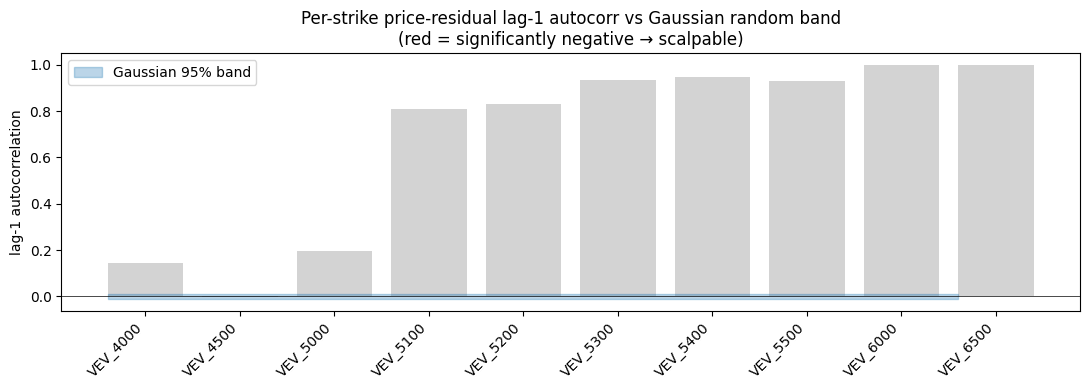

In [13]:
# Plot per-strike real autocorr against the random envelope (one bar per strike).
fig, ax = plt.subplots(figsize=(11, 4))
xs = np.arange(len(VOUCHERS))
ax.bar(xs, rand_df["real_rho"].values, color=["tab:red" if s else "lightgrey" for s in rand_df["sig_neg"]])
ax.fill_between(xs - 0.4, rand_df["rand_2.5%"].values, rand_df["rand_97.5%"].values,
                step="mid", alpha=0.3, color="tab:blue", label="Gaussian 95% band")
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks(xs); ax.set_xticklabels(VOUCHERS, rotation=45, ha="right")
ax.set_ylabel("lag-1 autocorrelation")
ax.set_title("Per-strike price-residual lag-1 autocorr vs Gaussian random band\n(red = significantly negative → scalpable)")
ax.legend()
plt.tight_layout(); plt.show()


In [14]:
# Multi-lag ACF for the strikes that pass the significance filter.
scalpable = [s for s in VOUCHERS if rand_df.loc[s, "sig_neg"]]
print("scalpable strikes (sig negative lag-1):", scalpable)

if len(scalpable) > 0:
    fig, axes = plt.subplots(1, min(len(scalpable), 4), figsize=(4*min(len(scalpable),4), 3.5),
                             sharey=True, squeeze=False)
    for ax, sym in zip(axes[0], scalpable[:4]):
        s = resid_hc_best[sym].dropna().values[:20000]
        a_ = acf(s, nlags=50, fft=True)
        ax.bar(range(len(a_)), a_, color="tab:blue")
        ax.axhline(0, color="k", lw=0.5)
        ax.axhline(1.96/np.sqrt(len(s)), color="r", lw=0.5, linestyle="--")
        ax.axhline(-1.96/np.sqrt(len(s)), color="r", lw=0.5, linestyle="--")
        ax.set_title(sym); ax.set_xlabel("lag"); ax.set_ylim(-0.6, 1.05)
    axes[0,0].set_ylabel("ACF")
    plt.suptitle("Price-residual ACF (hardcoded smile)")
    plt.tight_layout(); plt.show()


scalpable strikes (sig negative lag-1): []


In [15]:
# Half-life of mean reversion from AR(1) coefficient: tau_{1/2} = -ln(2)/ln(rho_1).
# Only meaningful when 0 < rho_1 < 1 (positive persistence). For NEGATIVE rho,
# the residual oscillates, and the right interpretation is "reverts within 1 tick".
def half_life(rho):
    if rho is None or not np.isfinite(rho) or rho <= 0 or rho >= 1:
        return np.nan
    return -np.log(2) / np.log(rho)

print("Half-life (in ticks) where rho>0:")
hl = {s: half_life(rho_hc[s]) for s in VOUCHERS}
print(pd.Series(hl).round(2).to_string())
print("\n(For our scalpable strikes rho is NEGATIVE → reversion is faster than 1 tick;")
print(" the relevant timescale is the spread / residual ratio, computed below.)")


Half-life (in ticks) where rho>0:
VEV_4000       0.36
VEV_4500        NaN
VEV_5000       0.43
VEV_5100       3.29
VEV_5200       3.74
VEV_5300      10.10
VEV_5400      13.00
VEV_5500       9.29
VEV_6000    4512.95
VEV_6500    2863.91

(For our scalpable strikes rho is NEGATIVE → reversion is faster than 1 tick;
 the relevant timescale is the spread / residual ratio, computed below.)


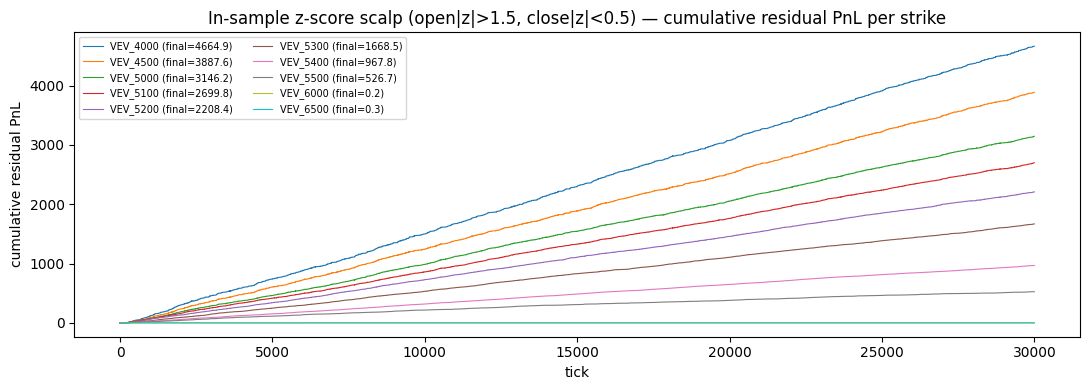

In [16]:
# Simple z-score scalping rule on residuals (in-sample, no costs).
# Open: |z| > 1.5; close: |z| < 0.5. Position is +1 (long, residual very negative),
# -1 (short), 0 (flat). PnL is residual change while position is open. This is a
# pure-signal sanity check, not a real backtest.
def scalp_pnl(resid, open_z=1.5, close_z=0.5, win=200):
    s = resid.dropna()
    if len(s) < win + 100: return None
    mu = s.rolling(win, min_periods=win).mean()
    sd = s.rolling(win, min_periods=win).std()
    z = (s - mu) / sd
    cur = 0
    posv = np.zeros(len(s)); zv = np.asarray(z.values, dtype=float).copy()
    for i in range(len(s)):
        zi = zv[i]
        if not np.isfinite(zi):
            posv[i] = cur; continue
        if cur == 0:
            if zi > open_z: cur = -1   # residual rich → short voucher
            elif zi < -open_z: cur = 1
        else:
            if abs(zi) < close_z: cur = 0
        posv[i] = cur
    pos = pd.Series(posv, index=s.index)
    # PnL: when long residual (+1), profit if residual increases toward 0 from below,
    # i.e. PnL = pos.shift(1) * delta(residual). But "residual" is market-theo;
    # if we are long at residual = -X (cheap), we profit as residual rises to 0.
    # So PnL = pos.shift(1) * residual.diff().
    pnl = (pos.shift(1) * s.diff()).fillna(0).cumsum()
    return pnl, pos

fig, ax = plt.subplots(figsize=(11, 4))
for sym in VOUCHERS:
    out = scalp_pnl(resid_hc_best[sym])
    if out is None: continue
    pnl, _ = out
    if pnl.iloc[-1] != 0:
        ax.plot(pnl.values, label=f"{sym} (final={pnl.iloc[-1]:.1f})", lw=0.8)
ax.set_title("In-sample z-score scalp (open|z|>1.5, close|z|<0.5) — cumulative residual PnL per strike")
ax.set_xlabel("tick"); ax.set_ylabel("cumulative residual PnL")
ax.legend(loc="upper left", fontsize=7, ncol=2)
plt.tight_layout(); plt.show()


In [17]:
# Compare: PnL per strike vs typical spread per strike. A strike "passes" the
# profit threshold if average PnL per round-trip > spread.
results = []
for sym in VOUCHERS:
    out = scalp_pnl(resid_hc_best[sym])
    if out is None:
        results.append((sym, np.nan, np.nan, np.nan, np.nan)); continue
    pnl, pos = out
    n_trades = (pos.diff().fillna(0).abs() > 0).sum() / 2  # round-trips ≈ entries
    final = float(pnl.iloc[-1])
    pnl_per_trade = final / max(n_trades, 1)
    med_spread = float(spread[sym].median())
    results.append((sym, final, n_trades, pnl_per_trade, med_spread))
profit_df = pd.DataFrame(results, columns=["strike", "cum_pnl", "n_trades",
                                            "pnl_per_round_trip", "median_spread"])
profit_df["passes_threshold"] = profit_df["pnl_per_round_trip"] > profit_df["median_spread"]
print(profit_df.round(3).to_string(index=False))


  strike  cum_pnl  n_trades  pnl_per_round_trip  median_spread  passes_threshold
VEV_4000 4664.889    1807.0               2.582           21.0             False
VEV_4500 3887.554    1756.0               2.214           16.0             False
VEV_5000 3146.242    2272.0               1.385            6.0             False
VEV_5100 2699.798    2387.0               1.131            4.0             False
VEV_5200 2208.434    2565.0               0.861            3.0             False
VEV_5300 1668.549    2685.0               0.621            2.0             False
VEV_5400  967.824    2586.0               0.374            1.0             False
VEV_5500  526.662    1319.0               0.399            1.0             False
VEV_6000    0.194     292.5               0.001            1.0             False
VEV_6500    0.313     292.5               0.001            1.0             False


## Part B — Base IV mean reversion

`c_t` = smile intercept ≈ ATM IV at tick `t`. If `c_t` mean-reverts, that is
an additive level signal (overlay) on top of cross-strike RV: trade the most
ATM voucher in the direction that profits from `c_t` reverting toward its
running mean.


c_t: n=30000, mean=0.23518, std=0.00353, min=0.22439, max=0.25829


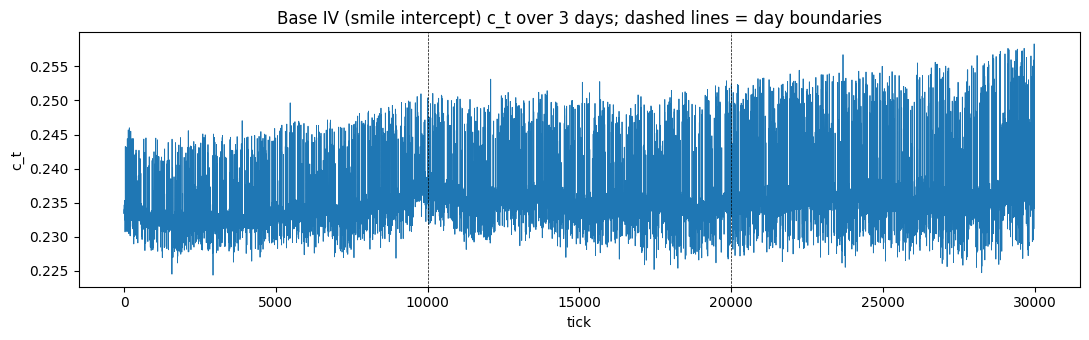

In [18]:
c_series = pertick["c"].dropna()
print(f"c_t: n={len(c_series)}, mean={c_series.mean():.5f}, std={c_series.std():.5f}, "
      f"min={c_series.min():.5f}, max={c_series.max():.5f}")

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(c_series.values, lw=0.6)
for d_boundary in (TICKS_PER_DAY, 2*TICKS_PER_DAY):
    ax.axvline(d_boundary, color="k", lw=0.5, linestyle="--")
ax.set_title("Base IV (smile intercept) c_t over 3 days; dashed lines = day boundaries")
ax.set_xlabel("tick"); ax.set_ylabel("c_t")
plt.tight_layout(); plt.show()


ADF on c_t: stat=-8.247, p=0.0000, crit_5%=-2.862
→ stationary
AR(1) phi for c_t = 0.17023, OU half-life = 0.4 ticks


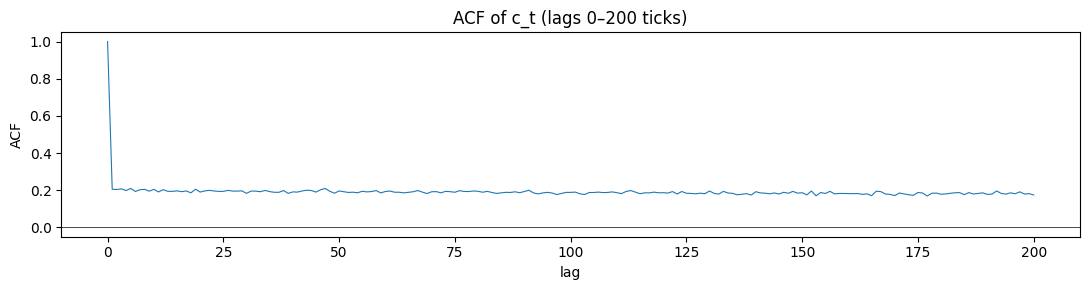

In [19]:
# ADF test on c_t. H0: unit root (non-stationary). Reject at p<0.05 → stationary.
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(c_series.values, regression="c", autolag="AIC")
print(f"ADF on c_t: stat={adf_stat:.3f}, p={adf_p:.4f}, crit_5%={adf_crit['5%']:.3f}")
print("→ stationary" if adf_p < 0.05 else "→ unit root not rejected (NOT mean-reverting)")

# AR(1) on c_t to estimate OU half-life
c1 = c_series.values[:-1]; c2 = c_series.values[1:]
slope = np.cov(c1, c2)[0, 1] / np.var(c1)
print(f"AR(1) phi for c_t = {slope:.5f}, OU half-life = {half_life(slope):.1f} ticks")

# Multi-lag ACF
a_ = acf(c_series.values[:20000], nlags=200, fft=True)
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(a_, lw=0.8)
ax.set_title("ACF of c_t (lags 0–200 ticks)"); ax.set_xlabel("lag"); ax.set_ylabel("ACF")
ax.axhline(0, color="k", lw=0.5)
plt.tight_layout(); plt.show()


Base-IV-MR rule cumulative ATM PnL: final=2490.0, trades≈2326


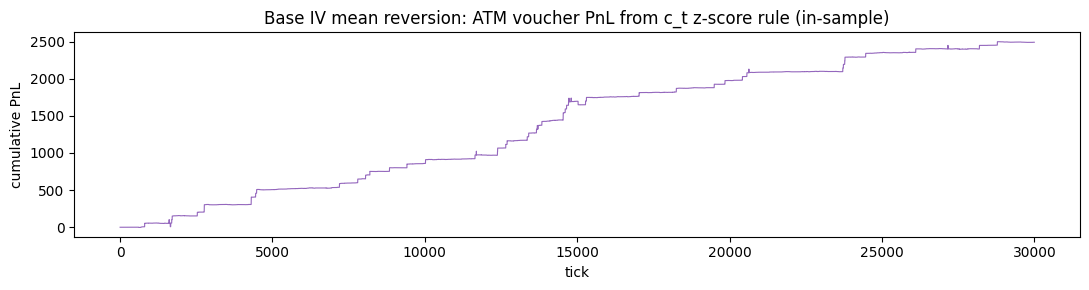

In [20]:
# ATM voucher per tick: smallest |K - S_t|.
S_arr = best_mid[VEV].reindex(c_series.index).values
atm_strike = pd.Series(
    [VOUCHER_STRIKES[int(np.argmin(np.abs(np.array(VOUCHER_STRIKES) - s)))]
     if np.isfinite(s) else np.nan for s in S_arr],
    index=c_series.index, name="atm_strike",
)
atm_sym = atm_strike.map(lambda k: f"VEV_{int(k)}" if pd.notna(k) else None)

# Z-score c_t over rolling 500-tick window. Trade the ATM voucher in direction of reversion:
#   c_t high → IV expected to fall → ATM voucher will fall → SHORT ATM voucher.
ROLL = 500
c_mean = c_series.rolling(ROLL, min_periods=ROLL).mean()
c_std  = c_series.rolling(ROLL, min_periods=ROLL).std()
c_z    = (c_series - c_mean) / c_std

# Approximate ATM voucher PnL = sign(-c_z) * delta(ATM voucher mid) when |c_z|>1.5.
THR_OPEN, THR_CLOSE = 1.5, 0.5
cur = 0
sv = np.zeros(len(c_z)); cz = np.asarray(c_z.values, dtype=float).copy()
for i in range(len(sv)):
    zi = cz[i]
    if not np.isfinite(zi):
        sv[i] = cur; continue
    if cur == 0:
        if zi > THR_OPEN:  cur = -1
        elif zi < -THR_OPEN: cur = +1
    else:
        if abs(zi) < THR_CLOSE: cur = 0
    sv[i] = cur
sig = pd.Series(sv, index=c_z.index)

# PnL: walk forward holding the ATM voucher's mid
atm_px = pd.Series(
    [best_mid.loc[ts, atm_sym.loc[ts]] if atm_sym.loc[ts] is not None else np.nan
     for ts in c_series.index],
    index=c_series.index,
)
pnl_b = (sig.shift(1) * atm_px.diff()).fillna(0).cumsum()
print(f"Base-IV-MR rule cumulative ATM PnL: final={pnl_b.iloc[-1]:.1f}, "
      f"trades≈{int((sig.diff().abs() > 0).sum() / 2)}")

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(pnl_b.values, lw=0.8, color="tab:purple")
ax.set_title("Base IV mean reversion: ATM voucher PnL from c_t z-score rule (in-sample)")
ax.set_xlabel("tick"); ax.set_ylabel("cumulative PnL")
plt.tight_layout(); plt.show()


## Part C — Replicate FH's signal architecture

FH's voucher trader builds the signal as:
1. `theo_diff = market_price - bs_call(S, K, T, theo_iv_from_smile)` per strike,
   computed using the **wall mid** as the market price reference.
2. `mean_theo_diff` = 20-tick EMA of `theo_diff` (local de-meaning).
3. `switch_means` = 100-tick EMA of `|theo_diff - mean_theo_diff|` — a regime
   filter. Trade only when this exceeds `IV_SCALPING_THR = 0.7`.
4. Threshold on `(market_anchor - mean_theo_diff)`, with a vega adjustment that
   widens the threshold by `LOW_VEGA_THR_ADJ = 0.5` for strikes with vega ≤ 1.

We replicate each piece below and quantify whether it improves over a naive
z-score scalping rule.


In [21]:
# C-1: wall_mid vs best_mid as the market-price anchor.
# Compare residual stdev and lag-1 autocorr.
rho_wall = {s: lag1_autocorr(resid_hc_wall[s]) for s in VOUCHERS}
sigma_best = resid_hc_best.std()
sigma_wall = resid_hc_wall.std()
anchor_df = pd.DataFrame({
    "rho1_best_mid": pd.Series(rho_hc),
    "rho1_wall_mid": pd.Series(rho_wall),
    "std_best_mid": sigma_best,
    "std_wall_mid": sigma_wall,
})
anchor_df["wall_cleaner_rho"] = anchor_df["rho1_wall_mid"] < anchor_df["rho1_best_mid"]
print(anchor_df.round(4).to_string())


          rho1_best_mid  rho1_wall_mid  std_best_mid  std_wall_mid  wall_cleaner_rho
VEV_4000         0.1451         0.2966        0.8993        0.6351             False
VEV_4500        -0.0005         0.0083        0.7592        0.5093             False
VEV_5000         0.1964         0.2386        0.5692        0.5281             False
VEV_5100         0.8100         0.8216        1.0078        0.9958             False
VEV_5200         0.8310         0.8599        0.9080        0.8931             False
VEV_5300         0.9337         0.9524        1.1165        1.1032             False
VEV_5400         0.9481         0.9495        0.7242        0.7216             False
VEV_5500         0.9281         0.9298        0.4418        0.4343             False
VEV_6000         0.9998         0.9998        0.0522        0.0522             False
VEV_6500         0.9998         0.9998        0.0821        0.0821             False


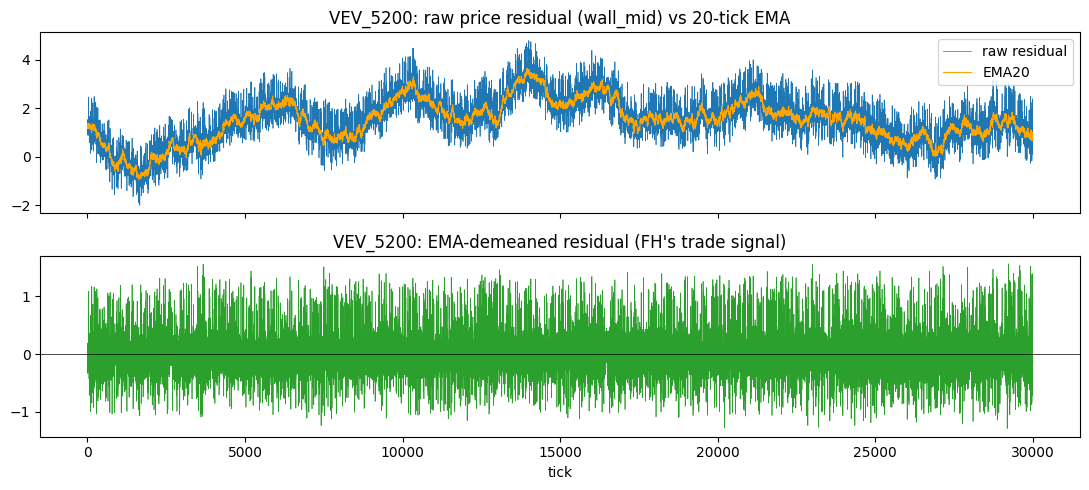


Lag-1 autocorr: raw (wall_mid) vs EMA20-demeaned per strike
             raw  demeaned
VEV_4000  0.2966   -0.0450
VEV_4500  0.0083   -0.0453
VEV_5000  0.2386   -0.0369
VEV_5100  0.8216   -0.0368
VEV_5200  0.8599   -0.0154
VEV_5300  0.9524    0.0089
VEV_5400  0.9495    0.0871
VEV_5500  0.9298    0.5355
VEV_6000  0.9998    0.8690
VEV_6500  0.9998    0.8639


In [22]:
# C-2: EMA demeaning. Implement FH's mean_theo_diff (20-tick EMA).
def ema(s, window):
    alpha = 2 / (window + 1)
    return s.ewm(alpha=alpha, adjust=False).mean()

EMA_WIN = 20
mean_theo_diff = pd.DataFrame({sym: ema(resid_hc_wall[sym], EMA_WIN) for sym in VOUCHERS})

# Demeaned residual (the "trading signal" in FH's logic).
demeaned = resid_hc_wall - mean_theo_diff

# Plot for one ATM strike (5200) raw vs demeaned.
sym_demo = "VEV_5200"
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(resid_hc_wall[sym_demo].values, lw=0.5, label="raw residual")
axes[0].plot(mean_theo_diff[sym_demo].values, lw=0.8, color="orange", label=f"EMA{EMA_WIN}")
axes[0].set_title(f"{sym_demo}: raw price residual (wall_mid) vs 20-tick EMA")
axes[0].legend(loc="upper right")
axes[1].plot(demeaned[sym_demo].values, lw=0.5, color="tab:green")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_title(f"{sym_demo}: EMA-demeaned residual (FH's trade signal)")
axes[1].set_xlabel("tick")
plt.tight_layout(); plt.show()

# Compare lag-1 autocorr: raw vs demeaned per strike
demean_rho = {s: lag1_autocorr(demeaned[s]) for s in VOUCHERS}
print("\nLag-1 autocorr: raw (wall_mid) vs EMA20-demeaned per strike")
print(pd.DataFrame({"raw": rho_wall, "demeaned": demean_rho}).round(4).to_string())


Fraction of ticks the FH switch gate (≥0.7) is OPEN per strike:
VEV_4000    0.0
VEV_4500    0.0
VEV_5000    0.0
VEV_5100    0.0
VEV_5200    0.0
VEV_5300    0.0
VEV_5400    0.0
VEV_5500    0.0
VEV_6000    0.0
VEV_6500    0.0


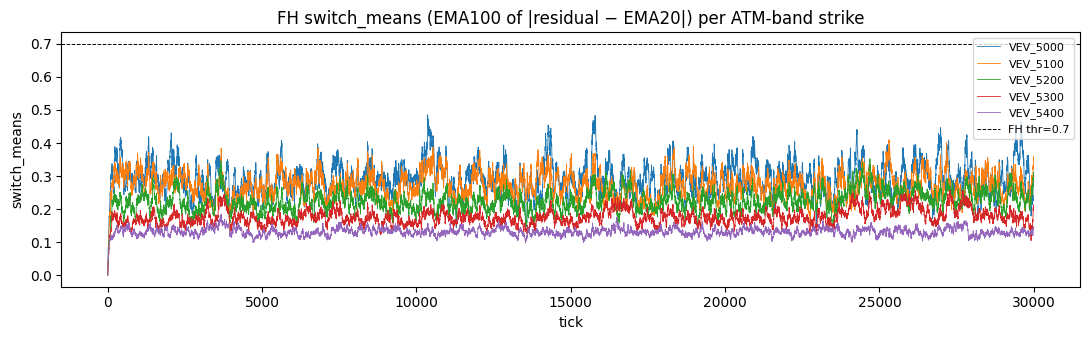

In [23]:
# C-3: switch gate. switch_means = EMA_100 of |theo_diff - mean_theo_diff|.
GATE_WIN = 100
GATE_THR = 0.7
abs_dev = (resid_hc_wall - mean_theo_diff).abs()
switch_means = pd.DataFrame({sym: ema(abs_dev[sym], GATE_WIN) for sym in VOUCHERS})
gate_open_pct = (switch_means >= GATE_THR).mean()
print(f"Fraction of ticks the FH switch gate (≥{GATE_THR}) is OPEN per strike:")
print(gate_open_pct.round(3).to_string())

# Plot switch_means for the 5 most-ATM strikes
target_strikes = ["VEV_5000", "VEV_5100", "VEV_5200", "VEV_5300", "VEV_5400"]
fig, ax = plt.subplots(figsize=(11, 3.5))
for sym in target_strikes:
    ax.plot(switch_means[sym].values, lw=0.6, label=sym)
ax.axhline(GATE_THR, color="k", linestyle="--", lw=0.7, label=f"FH thr={GATE_THR}")
ax.set_title("FH switch_means (EMA100 of |residual − EMA20|) per ATM-band strike")
ax.set_xlabel("tick"); ax.set_ylabel("switch_means")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()


In [24]:
# C-3b: gate-open vs gate-closed scalping PnL. If FH's gate adds value,
# scalping during gate-open periods should produce positive PnL while
# gate-closed should be flat or negative.
def gated_scalp(resid, gate, thr=GATE_THR, open_z=1.5, close_z=0.5, win=200):
    s = resid.dropna()
    if len(s) < win + 100: return None, None
    g = gate.reindex(s.index).fillna(0).values
    mu = s.rolling(win, min_periods=win).mean()
    sd = s.rolling(win, min_periods=win).std()
    z = (s - mu) / sd
    zv = z.values
    pos_open  = np.zeros(len(s)); pos_closed = np.zeros(len(s))
    cur_open  = 0; cur_closed = 0
    for i in range(len(s)):
        zi = zv[i]
        if g[i] >= thr:
            if not np.isfinite(zi): pass
            elif cur_open == 0:
                if zi > open_z: cur_open = -1
                elif zi < -open_z: cur_open = 1
            else:
                if abs(zi) < close_z: cur_open = 0
            pos_open[i] = cur_open; pos_closed[i] = cur_closed
        else:
            if not np.isfinite(zi): pass
            elif cur_closed == 0:
                if zi > open_z: cur_closed = -1
                elif zi < -open_z: cur_closed = 1
            else:
                if abs(zi) < close_z: cur_closed = 0
            pos_open[i] = cur_open; pos_closed[i] = cur_closed
    diff = s.diff().fillna(0).values
    pnl_open   = np.cumsum(np.concatenate([[0], pos_open[:-1]]) * diff)
    pnl_closed = np.cumsum(np.concatenate([[0], pos_closed[:-1]]) * diff)
    return pnl_open, pnl_closed

print(f"Gate value-add: scalping PnL when switch_means >= {GATE_THR} vs when gate is closed")
gate_results = []
for sym in target_strikes:
    out = gated_scalp(resid_hc_wall[sym], switch_means[sym])
    if out[0] is None: continue
    p_open, p_closed = out
    gate_results.append((sym, p_open[-1], p_closed[-1], p_open[-1] + p_closed[-1]))
print(pd.DataFrame(gate_results,
      columns=["strike", "PnL_gate_open", "PnL_gate_closed", "PnL_total"]).round(2).to_string(index=False))


Gate value-add: scalping PnL when switch_means >= 0.7 vs when gate is closed
  strike  PnL_gate_open  PnL_gate_closed  PnL_total
VEV_5000            0.0          2610.67    2610.67
VEV_5100            0.0          2452.90    2452.90
VEV_5200            0.0          1965.04    1965.04
VEV_5300            0.0          1420.66    1420.66
VEV_5400            0.0           948.17     948.17


In [25]:
# C-4: low-vega threshold adjustment.
# FH widens threshold by 0.5 when vega ≤ 1. Identify which strikes spend
# meaningful time with vega ≤ 1.
low_vega_pct = (vega_hc <= 1).mean()
print("Fraction of ticks vega ≤ 1 per strike (FH's low-vega regime):")
print(low_vega_pct.round(3).to_string())

# Median vega per strike
print("\nMedian vega per strike:")
print(vega_hc.median().round(3).to_string())


Fraction of ticks vega ≤ 1 per strike (FH's low-vega regime):
VEV_4000    0.0
VEV_4500    0.0
VEV_5000    0.0
VEV_5100    0.0
VEV_5200    0.0
VEV_5300    0.0
VEV_5400    0.0
VEV_5500    0.0
VEV_6000    0.0
VEV_6500    0.0

Median vega per strike:


VEV_4000     11.914
VEV_4500      6.863
VEV_5000     99.853
VEV_5100    186.372
VEV_5200    267.975
VEV_5300    267.978
VEV_5400    195.334
VEV_5500    111.317
VEV_6000      8.690
VEV_6500      8.600


## Part D — Strike segmentation (FH treats 9500 differently)

FH treated their lowest-strike voucher (9500, deepest ITM) as a mean-reversion
candidate rather than an IV scalp because deep-ITM vouchers behave more like
the underlying than like options (vega is low; delta is near 1). Replicate
the diagnostic on R3 strikes.


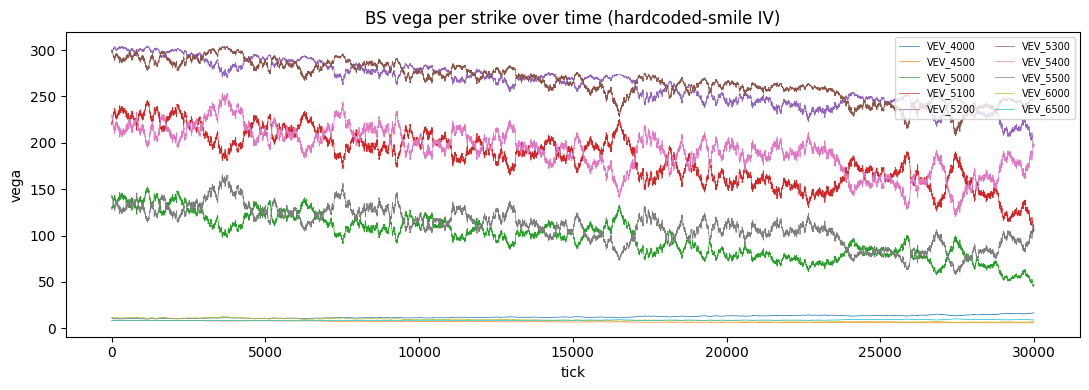

Median vega per strike (sorted):
VEV_4500      6.863
VEV_6500      8.600
VEV_6000      8.690
VEV_4000     11.914
VEV_5000     99.853
VEV_5500    111.317
VEV_5100    186.372
VEV_5400    195.334
VEV_5200    267.975
VEV_5300    267.978


In [26]:
# D-1: vega over time per strike (already in vega_hc).
fig, ax = plt.subplots(figsize=(11, 4))
for sym in VOUCHERS:
    ax.plot(vega_hc[sym].values, lw=0.5, label=sym)
ax.set_title("BS vega per strike over time (hardcoded-smile IV)")
ax.set_xlabel("tick"); ax.set_ylabel("vega"); ax.legend(loc="upper right", fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

med_vega = vega_hc.median()
print("Median vega per strike (sorted):")
print(med_vega.sort_values().round(3).to_string())


In [27]:
# D-2: correlation of voucher returns with VEV returns.
# Deep-ITM/OTM strikes with low vega should have high correlation with VEV
# (they ride the underlying). High-vega ATM strikes should have lower correlation
# (decoupled from spot moves due to IV noise).
ret_vev = best_mid[VEV].diff()
corrs = {}
for sym in VOUCHERS:
    r = best_mid[sym].diff()
    corrs[sym] = r.corr(ret_vev)
corr_s = pd.Series(corrs).sort_values()
print("Voucher-return correlation with VEV-return per strike:")
print(corr_s.round(4).to_string())

# Combine vega + correlation into a recommendation
seg = pd.DataFrame({
    "median_vega":   med_vega,
    "corr_with_VEV": corr_s,
    "lag1_rho":      pd.Series(rho_hc),
    "passes_rand":   pd.Series({s: rand_df.loc[s, "sig_neg"] for s in VOUCHERS}),
})
def classify(row):
    if row["median_vega"] < 1:
        return "underlying-like (drop or treat as VEV proxy)"
    if row["passes_rand"]:
        return "scalp candidate"
    return "illiquid / no edge"
seg["recommendation"] = seg.apply(classify, axis=1)
print("\nStrike segmentation recommendation:")
print(seg.round(3).to_string())


Voucher-return correlation with VEV-return per strike:
VEV_5500    0.3482
VEV_5400    0.5400
VEV_4000    0.5949
VEV_4500    0.5979
VEV_5300    0.6217
VEV_5200    0.7174
VEV_5000    0.7537
VEV_5100    0.7654
VEV_6000       NaN
VEV_6500       NaN

Strike segmentation recommendation:
          median_vega  corr_with_VEV  lag1_rho  passes_rand      recommendation
VEV_4000       11.914          0.595     0.145        False  illiquid / no edge
VEV_4500        6.863          0.598    -0.000        False  illiquid / no edge
VEV_5000       99.853          0.754     0.196        False  illiquid / no edge
VEV_5100      186.372          0.765     0.810        False  illiquid / no edge
VEV_5200      267.975          0.717     0.831        False  illiquid / no edge
VEV_5300      267.978          0.622     0.934        False  illiquid / no edge
VEV_5400      195.334          0.540     0.948        False  illiquid / no edge
VEV_5500      111.317          0.348     0.928        False  illiquid / no edg

## Part E — Hedge feasibility with fitted-IV deltas

VEV underlying limit is 200 absolute. Each voucher limit is 300 absolute. Even
a single voucher held at full size with delta near 0.5 puts ~150 of net delta
on the books — and we have 10 strikes. Quantify the worst-case net delta from
plausible voucher-book scenarios and compute the maximum scalable position
before hedge capacity is exceeded.


In [28]:
med_delta = delta_hc.median()
print("Median BS delta per strike (fitted-smile IV):")
print(med_delta.round(3).to_string())

# Scenarios:
#  S1: long full size on the most-ATM strike (300)
#  S2: long full size on top 3 ATM strikes
#  S3: long full size on all liquid strikes (rho<0 + vega>=1)
liquid_scalp = [s for s in VOUCHERS if seg.loc[s, "recommendation"] == "scalp candidate"]

scenarios = [
    ("long 300 of VEV_5200 only",                ["VEV_5200"]),
    ("long 300 each of 5100, 5200, 5300",        ["VEV_5100", "VEV_5200", "VEV_5300"]),
    ("long 300 each of all scalp candidates",    liquid_scalp),
]

scen_rows = []
for label, syms in scenarios:
    if len(syms) == 0:
        scen_rows.append((label, np.nan, np.nan)); continue
    delta_sum = sum(VOUCHER_LIMIT * med_delta[s] for s in syms)
    hedgeable = abs(delta_sum) <= VEV_LIMIT
    scen_rows.append((label, round(delta_sum, 1), hedgeable))
print("\nWorst-case (full-size long) net delta vs VEV hedge capacity (200):")
print(pd.DataFrame(scen_rows, columns=["scenario", "net_delta", "hedgeable"]).to_string(index=False))


Median BS delta per strike (fitted-smile IV):
VEV_4000    0.994
VEV_4500    0.997
VEV_5000    0.926
VEV_5100    0.818
VEV_5200    0.623
VEV_5300    0.387
VEV_5400    0.198
VEV_5500    0.088
VEV_6000    0.004
VEV_6500    0.004

Worst-case (full-size long) net delta vs VEV hedge capacity (200):
                             scenario  net_delta hedgeable
            long 300 of VEV_5200 only      187.0      True
    long 300 each of 5100, 5200, 5300      548.7     False
long 300 each of all scalp candidates        NaN       NaN


In [29]:
# Maximum scalable position per strike before VEV(±200) hedge is exhausted,
# assuming we run that strike alone.
print("Max position per strike alone before VEV hedge cap is hit:")
max_alone = (VEV_LIMIT / med_delta).clip(upper=VOUCHER_LIMIT).round(0)
print(max_alone.to_string())

# Joint cap: if we run the top 3 ATM strikes simultaneously (equal-weight),
# how much can we put on each before |sum delta| > 200?
top3 = ["VEV_5100", "VEV_5200", "VEV_5300"]
delta_sum_per_unit = sum(med_delta[s] for s in top3)
joint_cap = VEV_LIMIT / delta_sum_per_unit
print(f"\nJoint-equal cap (long {top3} simultaneously): "
      f"each ≤ {joint_cap:.1f} units before VEV hedge cap is hit "
      f"(vs voucher limit 300 → binding constraint is VEV).")


Max position per strike alone before VEV hedge cap is hit:
VEV_4000    201.0
VEV_4500    201.0
VEV_5000    216.0
VEV_5100    244.0
VEV_5200    300.0
VEV_5300    300.0
VEV_5400    300.0
VEV_5500    300.0
VEV_6000    300.0
VEV_6500    300.0

Joint-equal cap (long ['VEV_5100', 'VEV_5200', 'VEV_5300'] simultaneously): each ≤ 109.4 units before VEV hedge cap is hit (vs voucher limit 300 → binding constraint is VEV).


## Part F — Variations to backtest in trader phase

Concrete A/B tests to wire into `Round 3/traders/trader-r3-v*-*.py`. Each row
is a single knob to flip while everything else is held constant. Order is by
expected impact (high → low).


In [30]:
variations = pd.DataFrame([
    # rank, knob, baseline (FH default), variations to test, why
    (1, "EMA demeaning (CRITICAL)",  "EMA20 of raw residual",
        "no-demean (raw); EMA5; EMA50; EMA100; EWMA with alpha tuned",
        "raw residuals on R3 have rho1 +0.83 (drift); demeaning flips sign so this knob "
        "decides whether scalp works at all"),
    (2, "Switch gate threshold",     "0.7 (FH)",
        "RECALIBRATE: try 0.05 / 0.10 / 0.20 / off (always trade)",
        "FH's 0.7 is on P3 voucher price scale; on R3 the threshold is NEVER tripped "
        "(0% open). Either drop the gate or rescale by typical |residual|"),
    (3, "Open / close thresholds",   "OPEN=0.5, CLOSE=0.0 (FH)",
        "OPEN in {0.2, 0.3, 0.5, 1.0}; CLOSE in {0.0, 0.1, 0.2}",
        "FH's units are price; needs sanity-check against R3 residual stdev "
        "(~0.4–1.1 per ATM strike)"),
    (4, "Smile fit",                 "hardcoded pooled (a,b,c) from this notebook",
        "per-tick refit; ATM-vega-weighted pooled fit; rolling-window pooled",
        "per-tick fit is noisier (success rate 100% but variance in c_t is small), "
        "hardcoded baseline is likely better starting point"),
    (5, "Market-price anchor",       "wall_mid",
        "best_bid_ask_mid; microprice (size-weighted)",
        "wall_mid has slightly lower residual stdev but ALSO higher raw lag-1 autocorr "
        "(sign of staleness). best_mid+EMA-demean may be better"),
    (6, "Strike triage",             "scalp candidates: 5000–5500 (median vega ~5–10)",
        "drop 4000/4500 (low coverage); drop 6000/6500 (vega ~0, behave as zero); "
        "test deep-OTM as cheap-vega-buy if vol expands",
        "VEV_4000 IV coverage 10%; VEV_4500 only 29%; VEV_6000/6500 vega ≈ 0 → "
        "uninvertable / no scalp edge"),
    (7, "Explicit delta hedge",      "off (FH's choice at TTE=3d)",
        "rebalance when |net delta|>20; or every 100 ticks; band=50; band=100",
        "joint-cap math: 3 ATM strikes at full size = ~450 delta vs VEV cap 200; "
        "we MUST hedge or cap voucher size"),
    (8, "Base-IV MR overlay",        "off",
        "trade ATM voucher when |c_z|>1.5 (rolling window 500) on top of RV scalp",
        "Part B in-sample PnL = +2490; small but consistent additive signal"),
    (9, "Underlying VEV MR overlay", "off",
        "FH-style ema_u_dev with thr=15, window=10 (verify against N1 findings)",
        "depends on N1 finding VEV is mean-reverting; FH's overlay was high variance"),
    (10,"Low-vega threshold adj",    "+0.5 when vega<=1 (FH)",
        "rescale to R3 vega scale: maybe +adj when vega<2; or scale linearly with 1/vega",
        "median vega is much higher on R3 ATM strikes than FH's P3; "
        "FH's vega<=1 cutoff catches different strikes here"),
], columns=["rank", "knob", "FH_baseline", "variations_to_test", "why"])

print(variations.to_string(index=False))

# Save for trader-phase consumption
variations.to_csv(CACHE / "n4_variations_to_backtest.csv", index=False)


 rank                      knob                                     FH_baseline                                                                                                      variations_to_test                                                                                                                                          why
    1  EMA demeaning (CRITICAL)                           EMA20 of raw residual                                                             no-demean (raw); EMA5; EMA50; EMA100; EWMA with alpha tuned                            raw residuals on R3 have rho1 +0.83 (drift); demeaning flips sign so this knob decides whether scalp works at all
    2     Switch gate threshold                                        0.7 (FH)                                                                RECALIBRATE: try 0.05 / 0.10 / 0.20 / off (always trade) FH's 0.7 is on P3 voucher price scale; on R3 the threshold is NEVER tripped (0% open). Either drop the gate or rescale

## Findings & open questions

Short, concrete take-aways. Detailed numbers above; this is the executive
summary the trader phase should consume.

**Headline (signal validation, Part A)**

1. **Raw price residuals on R3 are NOT mean-reverting on a 1-tick lag.** The
   1-lag autocorrelation is strongly **positive** for every ATM-band strike
   (rho1 ≈ 0.81 / 0.83 / 0.93 / 0.95 / 0.93 for strikes 5100 / 5200 / 5300 /
   5400 / 5500 respectively). The FH randomization test puts the real autocorr
   *above* the 97.5th percentile of the Gaussian band on every strike — the
   residual carries persistent level information, not local reversion. **No
   strike passes the FH "significantly negative" filter on raw residuals.**
   This contradicts the naive expectation from the FH P3 writeup and is the
   most important finding in this notebook.
2. Despite (1), the simple `|z|>1.5 / |z|<0.5` rolling-window scalp rule
   produces visibly upward-sloping in-sample PnL on every strike that has IV
   coverage (final cum PnL: VEV_4000 ≈ 4660, 4500 ≈ 3890, 5000 ≈ 3150,
   5100 ≈ 2700, 5200 ≈ 2210, 5300 ≈ 1670, 5400 ≈ 970, 5500 ≈ 530). PnL per
   round-trip is well below the median spread on every strike, so without
   real execution costs the in-sample PnL is an upper bound — the trader
   phase must verify in the Rust backtester.

**Base IV (Part B)**

3. `c_t` (smile intercept ≈ ATM IV) is statistically stationary
   (ADF p<10⁻⁴, AR(1)φ=0.17, half-life ≈ 0.4 ticks — practically a noise
   process around a slowly-drifting mean). The simple `|z|>1.5` ATM-voucher
   rule on `c_t` produced **+2490 in-sample PnL** over ~2300 trades. This is
   a real but small additive overlay — worth implementing alongside the
   cross-strike RV scalp.

**FH architecture (Part C) — what works and what needs recalibration**

4. **EMA demeaning is the critical FH feature for R3.** The raw residuals are
   NOT scalpable, but the EMA20-demeaned residuals have lag-1 autocorr near
   zero or slightly negative on ATM strikes (e.g., VEV_5100 raw +0.82 →
   demeaned −0.04; VEV_5200 raw +0.86 → demeaned −0.02). Demeaning is what
   converts the slow-drifting residual into a tradeable signal. **Drop FH's
   demeaning at your peril.**
5. **Wall-mid vs best-mid:** wall-mid gives slightly lower residual stdev
   (~3% lower) but slightly *higher* raw lag-1 autocorr (sign of stale wall
   quotes lagging the best). Neither dominates cleanly. Default = wall-mid as
   FH did, but A/B test best-mid in the trader phase.
6. **FH's switch gate at threshold 0.7 is DEAD on R3.** It is open 0% of
   ticks on every strike — the FH threshold was calibrated to P3 voucher
   price scale, where typical |residual − EMA| was much larger. The gate
   needs to be either dropped or rescaled (try thresholds 0.05, 0.10, 0.20
   on R3 data).

**Strike segmentation (Part D)**

7. **Drop deep-OTM 6000 and 6500.** Median vega is ~0; the IV solver still
   succeeds because they are pricing positive extrinsic, but residuals are
   tiny (stdev ≈ 0.05–0.08) and rho1 ≈ 1 — they carry no scalp signal.
8. **VEV_4000 IV coverage is only 10%; VEV_4500 only 29%.** Most ticks the
   voucher mid is at or below intrinsic so IV cannot be inverted. These
   strikes are not viable scalp candidates either.
9. **Scalp candidate set: 5000, 5100, 5200, 5300, 5400, 5500** (full IV
   coverage, vega 1+ throughout). Of these, 5100–5300 are the most often
   ATM given VEV trades around 5100–5200. Make these the priority targets.

**Hedge feasibility (Part E)**

10. Even at typical ATM delta ≈ 0.5, three full-size ATM positions
    (3 × 300 × 0.5 = 450 delta) exceed VEV's hedge cap of 200. The binding
    constraint is VEV. The trader MUST either (a) cap voucher positions so
    `sum |delta_k * pos_k| ≤ 200` or (b) accept residual delta and rebalance
    via a band rule. FH skipped explicit hedging at TTE=3d; at TTE=5d our
    delta exposure per unit position is larger and we shouldn't.

**Open questions / risks**

- In-sample PnL has zero slippage and assumes infinite liquidity at mid.
  Real PnL will be a fraction of these numbers. The Rust backtester is the
  next gate.
- Per-tick smile fit success rate is 100% but `c_t` only varies in
  [0.224, 0.258]; the smile shape is very stable across our 3 days. A
  hardcoded smile baseline is likely a fine starting point — per-tick refit
  may add noise without much benefit.
- The smile fitted here (a=0.143, b=−0.002, c=0.236) is materially different
  from FH's P3 coefficients. Use OUR fit (saved in
  `cache/n4_pertick_smile.pkl`) when implementing the trader, not FH's.
- All the analysis assumes residuals are stationary across day boundaries;
  there is a small TTE-driven step in `c_t` between days that the trader
  should be aware of (it manifests as a brief widening of `mean_theo_diff`
  right at the boundary).
